<h1>Midterm Exam - CHICAGO CRIMES ANALYTICS</h1>
<hr>
<h2>Analyst: Margarette Ann Felonia</h2>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

<h2>Converting Dataset(s) into Dataframe</h2>
<hr>

In [2]:
crimes = pd.read_csv("datasets//Chicago_Crimes.csv")

In [3]:
crimes

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13439321,JH237424,04/14/2024 12:00:00 AM,040XX S PRAIRIE AVE,0890,THEFT,FROM BUILDING,APARTMENT,False,False,...,3,38.0,06,1178707.0,1878256.0,2024,12/21/2024 03:40:46 PM,41.821236,-87.619921,"(41.821236024, -87.619920712)"
1,13437420,JH234779,04/14/2024 12:00:00 AM,023XX W CERMAK RD,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,COMMERCIAL / BUSINESS OFFICE,False,False,...,25,31.0,26,1161210.0,1889347.0,2024,12/21/2024 03:40:46 PM,41.852052,-87.683801,"(41.852051675, -87.683800849)"
2,13428676,JH224478,04/14/2024 12:00:00 AM,043XX W LE MOYNE ST,0917,MOTOR VEHICLE THEFT,"CYCLE, SCOOTER, BIKE WITH VIN",STREET,False,False,...,36,23.0,07,1146960.0,1909501.0,2024,12/21/2024 03:40:46 PM,41.907640,-87.735587,"(41.907640473, -87.735587478)"
3,13429357,JH225293,04/14/2024 12:00:00 AM,039XX W ADAMS ST,143A,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,STREET,True,False,...,28,26.0,15,1150158.0,1898721.0,2024,12/21/2024 03:40:46 PM,41.877997,-87.724121,"(41.877997275, -87.724120826)"
4,13430098,JH226395,04/14/2024 12:00:00 AM,011XX W 112TH PL,0890,THEFT,FROM BUILDING,RESIDENCE,False,False,...,21,75.0,06,1170856.0,1830157.0,2024,12/21/2024 03:40:46 PM,41.689421,-87.650123,"(41.6894214, -87.650123247)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249118,13805239,JJ217509,04/12/2025 12:00:00 AM,029XX W LOGAN BLVD,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,APARTMENT,False,False,...,1,22.0,26,1156478.0,1917149.0,2025,04/19/2025 03:41:24 PM,41.928440,-87.700416,"(41.928439867, -87.700415972)"
249119,13804023,JJ215813,04/12/2025 12:00:00 AM,094XX S HARVARD AVE,0430,BATTERY,AGGRAVATED - OTHER DANGEROUS WEAPON,STREET,False,False,...,9,49.0,04B,1175694.0,1842631.0,2025,04/19/2025 03:41:24 PM,41.723545,-87.632040,"(41.723545182, -87.632039508)"
249120,13803926,JJ215943,04/12/2025 12:00:00 AM,084XX S VINCENNES AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,21,71.0,08B,1173850.0,1848976.0,2025,04/19/2025 03:41:24 PM,41.740998,-87.638606,"(41.74099774, -87.638606337)"
249121,13803475,JJ215338,04/12/2025 12:00:00 AM,050XX S ABERDEEN ST,0530,ASSAULT,AGGRAVATED - OTHER DANGEROUS WEAPON,STREET,True,False,...,20,61.0,04A,1169838.0,1871348.0,2025,04/19/2025 03:41:24 PM,41.802477,-87.652657,"(41.802477219, -87.652657244)"


In [4]:
crimes.describe()

,ID,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude
count,2.491230e+05,249123.000000,249123.000000,249123.000000,249120.000000,2.490330e+05,2.490330e+05,249123.000000,249033.000000,249033.000000
mean,1.358652e+07,1153.845634,11.308924,23.186823,36.238560,1.165309e+06,1.887602e+06,2024.241668,41.847162,-87.668845
std,6.473192e+05,707.959752,7.074807,13.925951,21.567485,1.616814e+04,3.146277e+04,0.428095,0.086517,0.058875
min,2.807300e+04,111.000000,1.000000,1.000000,1.000000,1.092647e+06,1.813897e+06,2024.000000,41.644590,-87.934567
25%,1.352322e+07,533.000000,5.000000,10.000000,22.000000,1.153981e+06,1.860560e+06,2024.000000,41.772706,-87.710071
50%,1.361560e+07,1034.000000,10.000000,23.000000,32.000000,1.167190e+06,1.894278e+06,2024.000000,41.865616,-87.661690
75%,1.370865e+07,1732.000000,17.000000,34.000000,53.000000,1.176662e+06,1.910282e+06,2024.000000,41.909711,-87.627233
max,1.381045e+07,2535.000000,31.000000,50.000000,77.000000,1.205119e+06,1.951517e+06,2025.000000,42.022559,-87.524531


In [5]:
crimes.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,249123.0,1.358652e+07,647319.161410,2.807300e+04,1.352322e+07,1.361560e+07,1.370865e+07,1.381045e+07
Beat,249123.0,1.153846e+03,707.959752,1.110000e+02,5.330000e+02,1.034000e+03,1.732000e+03,2.535000e+03
District,249123.0,1.130892e+01,7.074807,1.000000e+00,5.000000e+00,1.000000e+01,1.700000e+01,3.100000e+01
Ward,249123.0,2.318682e+01,13.925951,1.000000e+00,1.000000e+01,2.300000e+01,3.400000e+01,5.000000e+01
Community Area,249120.0,3.623856e+01,21.567485,1.000000e+00,2.200000e+01,3.200000e+01,5.300000e+01,7.700000e+01
X Coordinate,249033.0,1.165309e+06,16168.139632,1.092647e+06,1.153981e+06,1.167190e+06,1.176662e+06,1.205119e+06
Y Coordinate,249033.0,1.887602e+06,31462.770629,1.813897e+06,1.860560e+06,1.894278e+06,1.910282e+06,1.951517e+06
Year,249123.0,2.024242e+03,0.428095,2.024000e+03,2.024000e+03,2.024000e+03,2.024000e+03,2.025000e+03
Latitude,249033.0,4.184716e+01,0.086517,4.164459e+01,4.177271e+01,4.186562e+01,4.190971e+01,4.202256e+01
Longitude,249033.0,-8.766884e+01,0.058875,-8.793457e+01,-8.771007e+01,-8.766169e+01,-8.762723e+01,-8.752453e+01


<h1>Checking the null values</h1>
<hr>

In [6]:
crimes.isnull().sum()

ID                        0
Case Number               0
Date                      0
Block                     0
IUCR                      0
Primary Type              0
Description               0
Location Description    857
Arrest                    0
Domestic                  0
Beat                      0
District                  0
Ward                      0
Community Area            3
FBI Code                  0
X Coordinate             90
Y Coordinate             90
Year                      0
Updated On                0
Latitude                 90
Longitude                90
Location                 90
dtype: int64

<h1>Filling the null values</h1>
<hr>

In [7]:
crimes['Community Area'] = crimes['Community Area'].fillna(crimes['Community Area'].mean())
crimes['X Coordinate'] = crimes['X Coordinate'].fillna(crimes['X Coordinate'].mean())
crimes['Y Coordinate'] = crimes['Y Coordinate'].fillna(crimes['Y Coordinate'].mean())
crimes['Latitude'] = crimes['Latitude'].fillna(crimes['Latitude'].mean())
crimes['Longitude'] = crimes['Longitude'].fillna(crimes['Longitude'].mean())
crimes['Location'] = crimes['Location'].fillna(crimes['Location'].mode()[0])
crimes['Location Description'] = crimes['Location Description'].fillna('unaccounted')


In [8]:
crimes.isnull().sum()

ID                      0
Case Number             0
Date                    0
Block                   0
IUCR                    0
Primary Type            0
Description             0
Location Description    0
Arrest                  0
Domestic                0
Beat                    0
District                0
Ward                    0
Community Area          0
FBI Code                0
X Coordinate            0
Y Coordinate            0
Year                    0
Updated On              0
Latitude                0
Longitude               0
Location                0
dtype: int64

In [9]:
crimes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249123 entries, 0 to 249122
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    249123 non-null  int64  
 1   Case Number           249123 non-null  object 
 2   Date                  249123 non-null  object 
 3   Block                 249123 non-null  object 
 4   IUCR                  249123 non-null  object 
 5   Primary Type          249123 non-null  object 
 6   Description           249123 non-null  object 
 7   Location Description  249123 non-null  object 
 8   Arrest                249123 non-null  bool   
 9   Domestic              249123 non-null  bool   
 10  Beat                  249123 non-null  int64  
 11  District              249123 non-null  int64  
 12  Ward                  249123 non-null  int64  
 13  Community Area        249123 non-null  float64
 14  FBI Code              249123 non-null  object 
 15  

<h1>Changing the Data type</h1>
<hr>

In [10]:
crimes['Case Number']= crimes['Case Number'].astype('category')
crimes['Date']= crimes['Date'].astype('category')
crimes['Block']= crimes['Block'].astype('category')
crimes['IUCR']= crimes['IUCR'].astype('category')
crimes['Primary Type']= crimes['Primary Type'].astype('category')
crimes['Description']= crimes['Description'].astype('category')
crimes['Location Description']= crimes['Location Description'].astype('category')
crimes['FBI Code']= crimes['FBI Code'].astype('category')
crimes['Updated On']= crimes['Updated On'].astype('category')
crimes['Location']= crimes['Location'].astype('category')


In [11]:
crimes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249123 entries, 0 to 249122
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   ID                    249123 non-null  int64   
 1   Case Number           249123 non-null  category
 2   Date                  249123 non-null  category
 3   Block                 249123 non-null  category
 4   IUCR                  249123 non-null  category
 5   Primary Type          249123 non-null  category
 6   Description           249123 non-null  category
 7   Location Description  249123 non-null  category
 8   Arrest                249123 non-null  bool    
 9   Domestic              249123 non-null  bool    
 10  Beat                  249123 non-null  int64   
 11  District              249123 non-null  int64   
 12  Ward                  249123 non-null  int64   
 13  Community Area        249123 non-null  float64 
 14  FBI Code              249123 non-nul

In [12]:
# Step 1: Convert to string only if not null
crimes['Date'] = crimes['Date'].astype(str)
# Step 2: Replace '/' with '-' safely
crimes['Date'] = crimes['Date'].replace('/', '-') 
# Step 3: Strip whitespace
crimes['Date'] = crimes['Date'].str.strip() 
# Step 4: Convert to datetime
crimes['Date'] = pd.to_datetime(crimes['Date'], dayfirst=True, errors='coerce')

In [13]:
crimes['Year'] = crimes['Date'].dt.year
crimes['Month'] =  crimes['Date'].dt.month
crimes['Day'] =  crimes['Date'].dt.day
crimes['DayOfWeek'] =  crimes['Date'].dt.dayofweek

In [14]:
crimes.isnull().sum()

ID                      0
Case Number             0
Date                    0
Block                   0
IUCR                    0
Primary Type            0
Description             0
Location Description    0
Arrest                  0
Domestic                0
Beat                    0
District                0
Ward                    0
Community Area          0
FBI Code                0
X Coordinate            0
Y Coordinate            0
Year                    0
Updated On              0
Latitude                0
Longitude               0
Location                0
Month                   0
Day                     0
DayOfWeek               0
dtype: int64

In [15]:
crimes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249123 entries, 0 to 249122
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   ID                    249123 non-null  int64         
 1   Case Number           249123 non-null  category      
 2   Date                  249123 non-null  datetime64[ns]
 3   Block                 249123 non-null  category      
 4   IUCR                  249123 non-null  category      
 5   Primary Type          249123 non-null  category      
 6   Description           249123 non-null  category      
 7   Location Description  249123 non-null  category      
 8   Arrest                249123 non-null  bool          
 9   Domestic              249123 non-null  bool          
 10  Beat                  249123 non-null  int64         
 11  District              249123 non-null  int64         
 12  Ward                  249123 non-null  int64         
 13 

<h1>Explanatory Data Analysis(EDA)</h1>
<hr>

<h3>1.) Which year recorded the highest number of crimes?</h3>

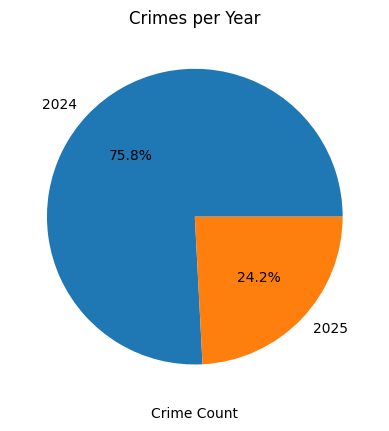

In [16]:
total_crime = crimes.groupby("Year").size()
    
total_crime.plot(
    kind="pie",
    autopct = '%1.1f%%', 
    title="Crimes per Year")
plt.xlabel("Crime Count")
plt.show()

<h5><b>INSIGHT:</b>The year with the highest total number of cases is 2024, accounting for approximately 75.8% of all recorded incidents. In comparison, 2025 counts for only 24.2% of the total. This indicates that the total number of cases in 2024 is nearly three times higher than that of 2025, highlighting a significant decline in reported incidents in the following year.</h5>

<h3>2.) What are the most common primary crime types?</h3>

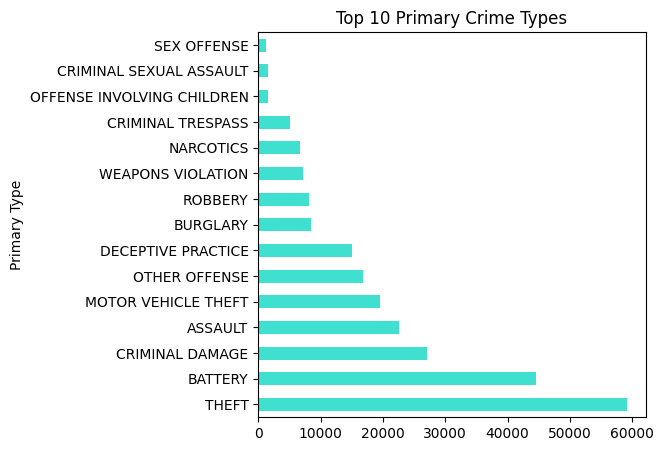

In [17]:
prime_types = crimes['Primary Type'].value_counts().head(15)
    
prime_types.plot(
    kind="barh", 
    figsize=(5,5),
    title="Top 10 Primary Crime Types",
    color="turquoise"
)
plt.show()

<h5><b>INSIGHT:</b>This chart presents the top 10 most common crimes in the dataset. The most frequently recorded offense is theft, with nearly 60,000 cases, representing approximately 98% of the total. This is followed by battery, with around 40,500 cases (75%). Motor vehicle theft, assault, and criminal damage each range between 20,000–30,000 cases (approximately 33%–50%), while the remaining offenses account for 20,000 cases or fewer, contributing the remaining 33%. Overall, the data indicate that property-related and violent crimes constitute the majority of reported incidents.</h5>

<h3>3.) What types of crimes most frequently occur in hospital buildings or grounds
 to the dataset?</h3>

<Axes: title={'center': 'Top Crimes in HOSPITAL BUILDING / GROUNDS'}, xlabel='Primary Type'>

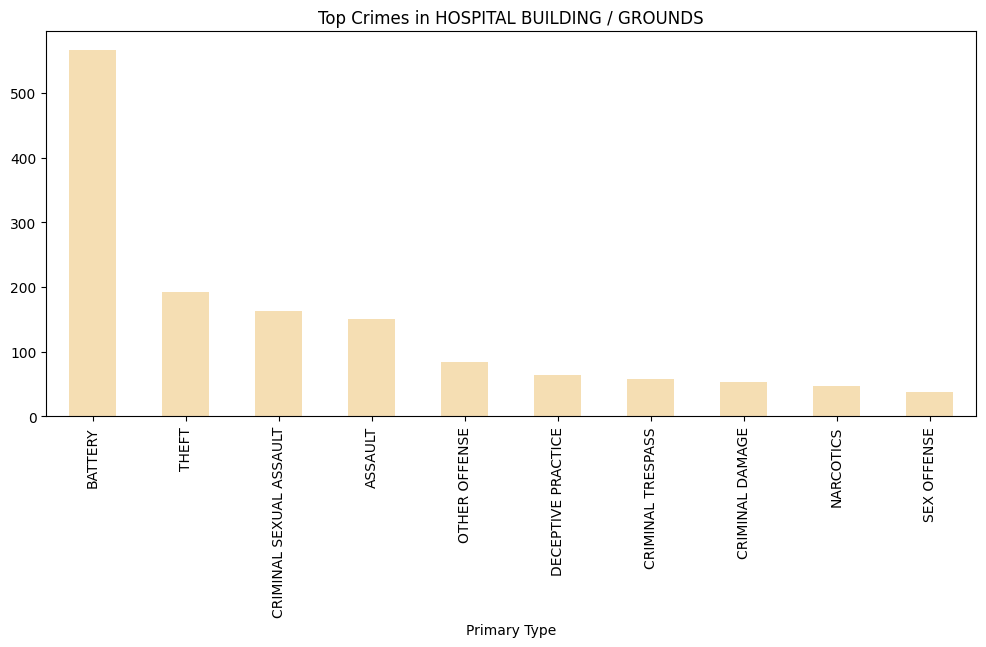

In [18]:
appartment_crimes = crimes[crimes["Location Description"] == "HOSPITAL BUILDING / GROUNDS"]
appartment_crimes["Primary Type"].value_counts().head(10).plot(
    kind="bar", 
    figsize=(12,5),
    title="Top Crimes in HOSPITAL BUILDING / GROUNDS",
    color="wheat"
)

<h5><b>INSIGHT:</b>The most frequent crime occurring in hospital buildings or grounds is battery, accounting for approximately 96% of cases. This is followed by theft at 33%, which is notably lower compared to battery incidents. Criminal sexual assault and assault account for 30% and 28%, respectively, while all other crimes fall below 16%. This highlights that physical offenses, particularly battery, dominate hospital-related crime reports.</h5>

<h3>4.) What are the top five most frequent types of crimes occurring at hotels and motels?</h3>

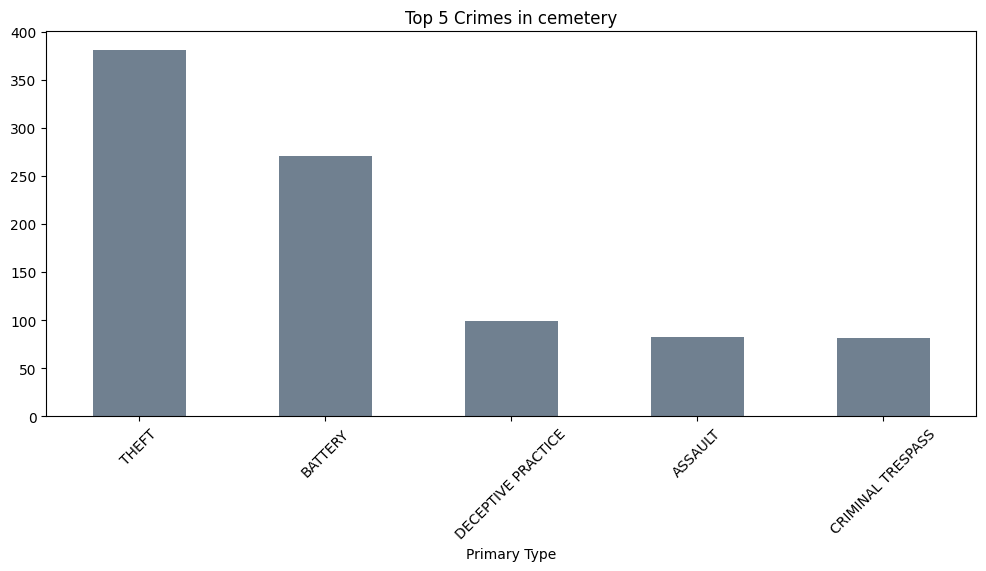

In [19]:
vehicle_crimes = crimes[crimes["Location Description"] == "HOTEL / MOTEL"]
vehicle_crimes["Primary Type"].value_counts().head(5).plot(
    kind="bar", 
    figsize=(12,5),
    title="Top 5 Crimes in cemetery",
    color="slategrey"
)
plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>In hotels and motels, theft is the most common crime, with 370 cases (92%), followed by battery with 250 cases (62%). Other offenses, including deceptive practice, assault, and criminal trespass, each range between 22–25%. These figures indicate that property-related and violent crimes are the most prevalent within hospitality settings.</h5>

<h3>5.) What type of crimes most often happen in Apartment according to the dataset?</h3>

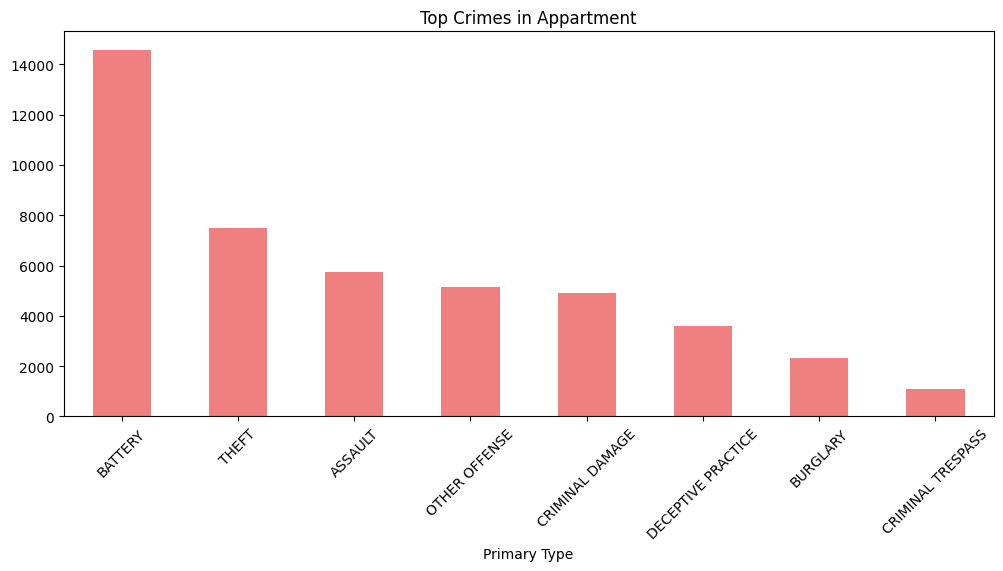

In [20]:
vehicle_crimes = crimes[crimes["Location Description"] == "APARTMENT"]
vehicle_crimes["Primary Type"].value_counts().head(8).plot(
    kind="bar", figsize=(12,5),
    title="Top Crimes in Appartment",
    color="lightcoral"
)

plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>Among apartment complexes, battery is the leading crime with 14,500 cases, followed by theft with 6,900 cases. Assault, other offenses, and criminal damage each have case counts between approximately 4,500–6,000, while criminal trespass represents one of the least frequent crimes with around 1,000 cases. This demonstrates that residential areas are particularly vulnerable to interpersonal and property-related offenses, with battery being the dominant concern.</h5>

<h3>6.) Which year recorded the highest number of arrests?</h3>

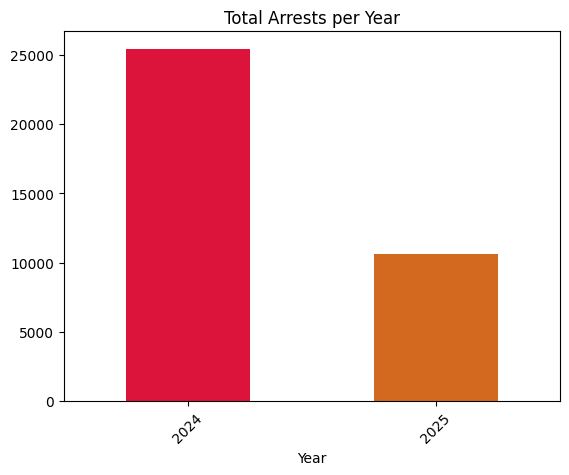

In [21]:
crimes.groupby("Year")["Arrest"].sum().plot(
    kind="bar", 
    title="Total Arrests per Year",
    color=["crimson","chocolate"]
)
plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>This plot illustrates the total number of arrests per year. The year 2024 recorded the highest number of arrests with 25,000 cases, whereas 2025 shows only 10,000 cases, likely because the year is not yet complete. Nevertheless, even considering this, 2024 clearly exhibits a significantly higher total number of arrests.</h5>

<h3>7.) How do arrest numbers vary across months?</h3>

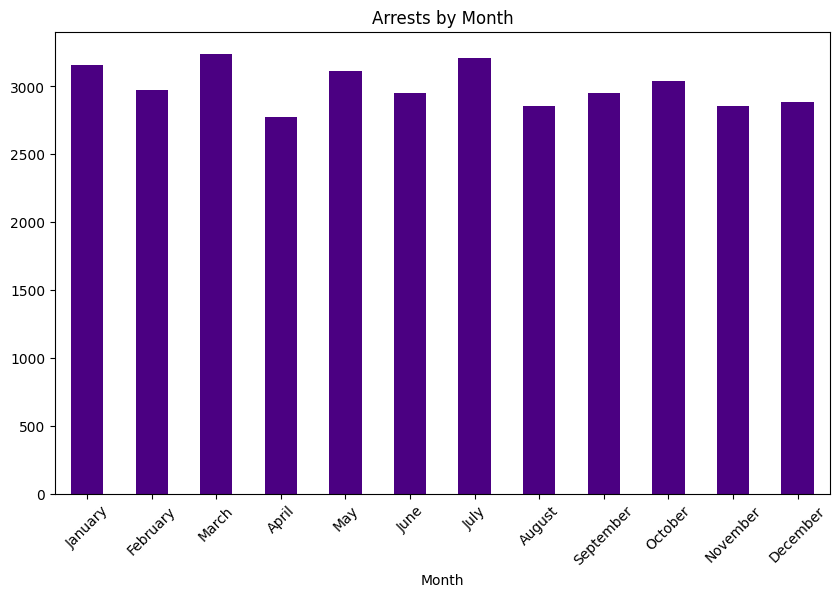

In [22]:
m_arrest = crimes.groupby("Month")["Arrest"].sum()
month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

m_arrest.index = m_arrest.index.map(month_names)
m_arrest.plot(
    kind="bar",
    title="Arrests by Month",
    color="indigo",
    figsize = (10,6)
)
plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>The monthly distribution of arrests indicates that the numbers remain relatively consistent across months. March and July recorded the highest arrests at approximately 3,500 cases, while the lowest monthly count is around 2,750 cases. The overall trend suggests no extreme fluctuations in arrest activity throughout the year.</h5>

<h3>8.) What is the monthly trend of arrests for battery crimes?</h3>

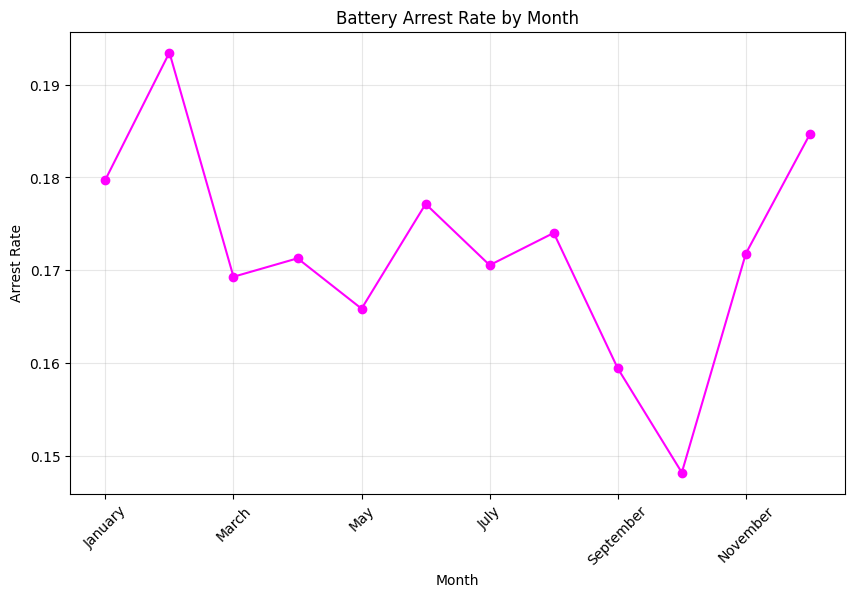

In [56]:

m_theft = crimes[crimes['Primary Type'] == "BATTERY"] 

m_theft_arrest = m_theft.groupby("Month")["Arrest"].mean()


month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
m_theft_arrest.index = m_theft_arrest.index.map(month_names)


m_theft_arrest.plot(
    kind='line',
    marker="o", 
    color="magenta",
    figsize = (10,6),
    title="Battery Arrest Rate by Month")
plt.ylabel("Arrest Rate")
plt.xlabel("Month")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>This line plot illustrates the monthly arrests for battery crimes. The highest number of arrests occurred in February, while October recorded the lowest arrest rate. Arrests then increased again in November and December, indicating a seasonal fluctuation in battery-related enforcement or reporting.</h5>

<h3>9.) Which month recorded the highest number of domestic crimes?</h3>

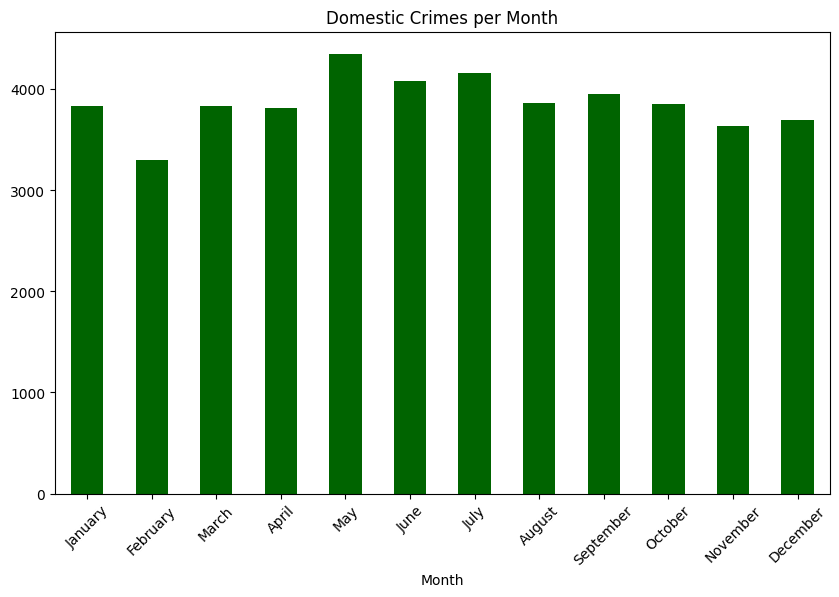

In [24]:
dcrimes = crimes.groupby("Month")["Domestic"].sum()

month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
dcrimes.index = dcrimes.index.map(month_names)

dcrimes.plot(
    kind="bar", 
    figsize = (10,6),
    color="darkgreen",
    title="Domestic Crimes per Month")
plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>The monthly records of domestic crimes show that May has the highest number of cases with 4,500 incidents, whereas February has the lowest at 3,300 cases (about 73% of the maximum). Additionally, January, March, April, August, and October exhibit similar counts, around 3,900 cases (87% of the maximum), indicating recurring patterns in domestic crime occurrences throughout the year.</h5>

<h3>10.) Which day of the week recorded the highest number of domestic crimes?
</h3>

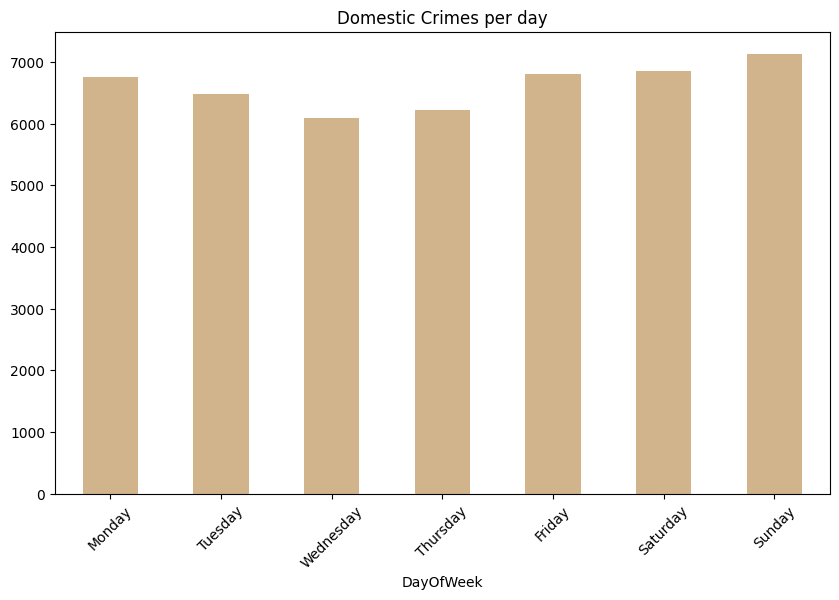

In [25]:
daycrimes = crimes.groupby("DayOfWeek")["Domestic"].sum()

day_names = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}
daycrimes.index = daycrimes.index.map(day_names)

daycrimes.plot(
    kind="bar",
    figsize = (10,6),
    color="tan",
    title="Domestic Crimes per day")
plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>The bar plot illustrates the distribution of domestic crimes across different days of the week. It is evident that Sunday records the highest number of domestic crimes, totaling 7,000 incidents, followed closely by Monday and Saturday with approximately 6,900 incidents each. Conversely, Wednesday has the lowest number of domestic crimes, with around 6,000 incidents, while the remaining days show totals ranging from 6,400 to 6,500 incidents.</h5>

<h3>11.) What are the most common crime locations?
</h3>

<Axes: title={'center': 'Top Crime Locations'}, ylabel='Location Description'>

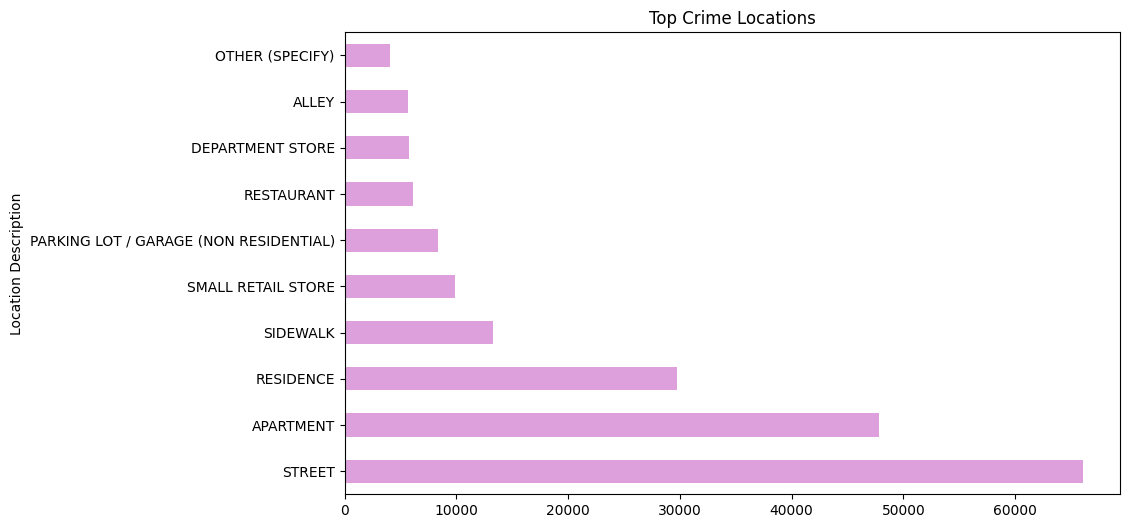

In [26]:
common_crime = crimes["Location Description"].value_counts().head(10)
    
common_crime.plot(kind="barh", 
                  figsize = (10,6),
                  color="plum",
                  title="Top Crime Locations")


<h5><b>INSIGHT:</b>The analysis of crime locations indicates that streets are the most common setting for crimes, with a total of 66,000 incidents, suggesting that many offenses occur outside the home. This is followed by apartments, which account for 48,000 incidents, representing approximately 72% of cases involving domestic crimes. Residences rank third with 30,000 incidents (44%), while other locations collectively account for 15,000 incidents (22%) or less. These findings highlight that both public spaces and residential areas are significant sites for criminal activity, with streets being the predominant location.</h5>

<h3>12.) Which district reports the highest number of narcotics-related crimes?

</h3>

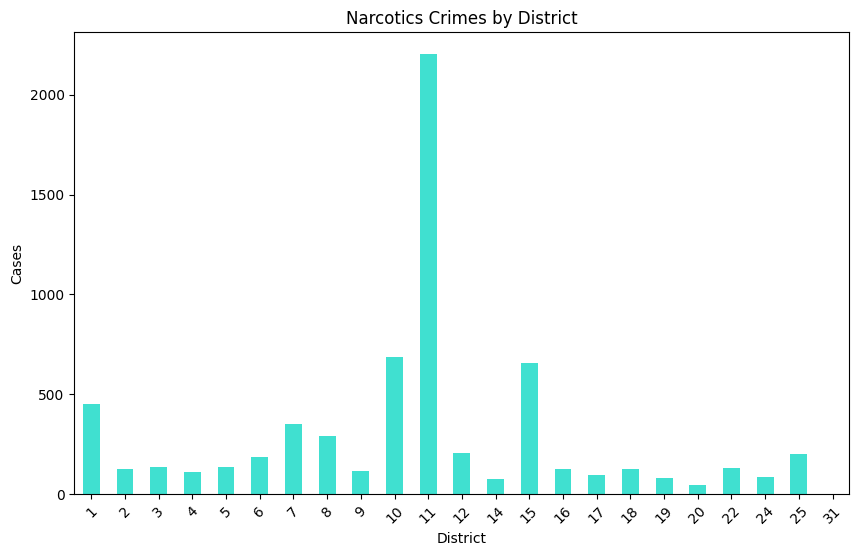

In [27]:
district_narcotics = crimes[crimes["Primary Type"]=="NARCOTICS"].groupby("District").size()
    
district_narcotics.plot(
    kind="bar", 
    title="Narcotics Crimes by District", 
    xlabel="District", 
    ylabel="Cases",
    color="turquoise",
    figsize = (10,6),
)
plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>This bar chart illustrates the distribution of narcotics-related crimes across different districts. District 11 records the highest number of cases, with over 2,200 incidents, followed by District 14 with approximately 650 cases, and District 10 with around 680 cases. The remaining districts show significantly lower counts, mostly under 500 cases, highlighting that narcotics offenses are highly concentrated in a few key districts, while the majority of districts experience comparatively minimal incidents.</h5>

<h3>13.) In which year were the fewest homicide cases recorded?
</h3>

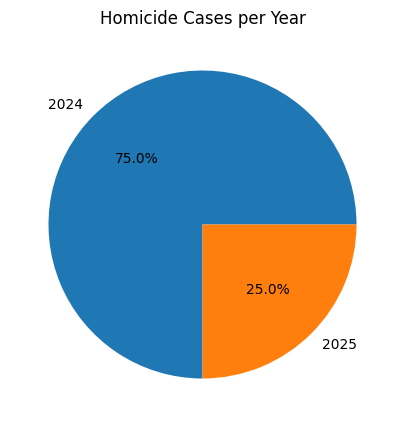

In [28]:
humantraffic = crimes[crimes["Primary Type"]=="HUMAN TRAFFICKING"].groupby("Year").size()
    
humantraffic.plot(
    kind="pie",
    autopct = '%1.1f%%',  
    figsize = (10,5),
    title="Homicide Cases per Year"
)
plt.show()

<h5><b>INSIGHT:</b>The pie chart illustrates the total number of homicide cases per year in the dataset. It shows that the year 2024 accounts for the highest percentage of cases at 75%, while 2025 accounts for only 25%. This indicates that the number of homicide cases in Chicago was significantly higher in 2024 compared to the current data for 2025.</h5>

<h3>14.) Which month usually records the highest number of homicide cases across different years?

</h3>

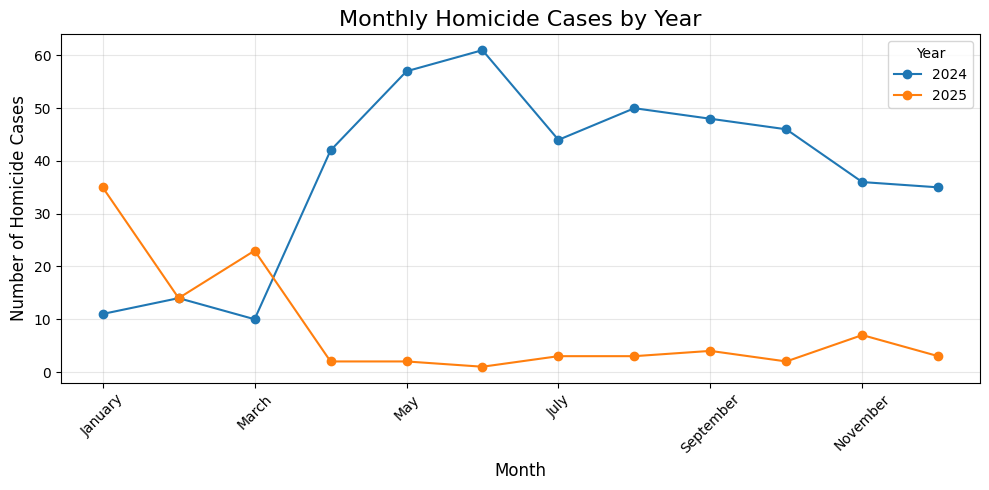

In [55]:
homicides = crimes[crimes["Primary Type"] == "HOMICIDE"]

monthly_homicides = homicides.groupby(["Year", "Month"]).size().reset_index(name="Count")


pivot_data = monthly_homicides.pivot(index="Month", columns="Year", values="Count")

month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

pivot_data.index = pivot_data.index.map(month_names)


pivot_data.plot(kind="line", marker="o", figsize=(10,5))

plt.title("Monthly Homicide Cases by Year", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Homicide Cases", fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend(title="Year")
plt.tight_layout()
plt.show()


<h5><b>INSIGHT:</b>The line plot illustrates the monthly homicide cases for the years 2024 and 2025. For 2024, the number of homicides shows a rising trend from January, peaking in June with 61 cases, before gradually declining towards the end of the year. Conversely, 2025 records significantly lower homicide cases throughout the year, with the highest numbers observed in January (35 cases) and March (23 cases), and the lowest in the mid-year months, where cases drop to 1–4 incidents per month.</h5>

<h3>15.) Which month records the highest number of “Offense Involving Children” cases?
</h3>

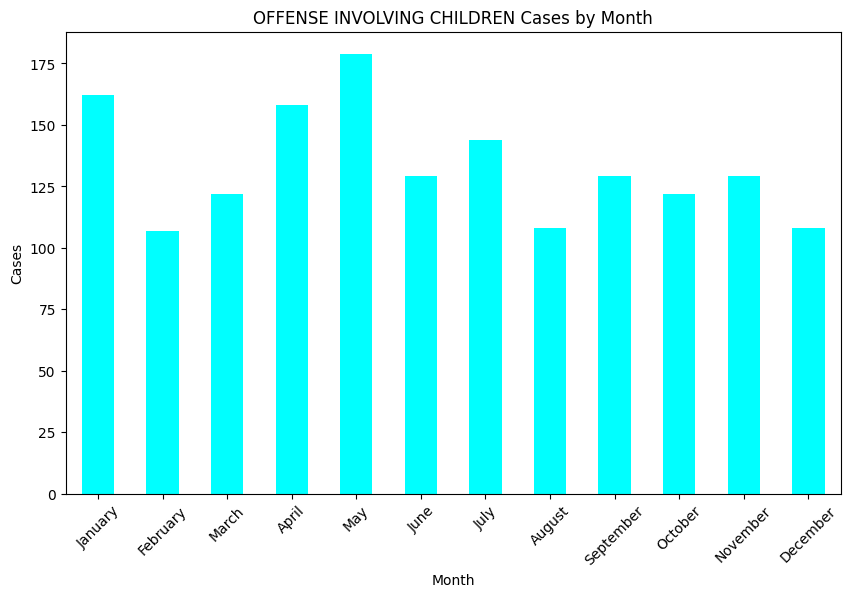

In [54]:
month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

offense_children = crimes[crimes["Primary Type"] == "OFFENSE INVOLVING CHILDREN"]
monthly_counts = offense_children.groupby("Month").size()


monthly_counts.index = monthly_counts.index.map(month_names)

monthly_counts.plot(
    kind="bar",
    title="OFFENSE INVOLVING CHILDREN Cases by Month",
    xlabel="Month",
    ylabel="Cases",
    color="cyan",
    figsize=(10,6)
)
plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>This bar plot illustrates the number of offense involving children cases recorded each month. May recorded the highest number of offense involving children cases, with approximately 175 cases. January recorded the lowest number of offense involving children cases, with approximately 100 cases. This suggests that offense involving children are more frequent in May</h5>

<h3>16.) On which day of the week are human trafficking cases most common?
</h3>

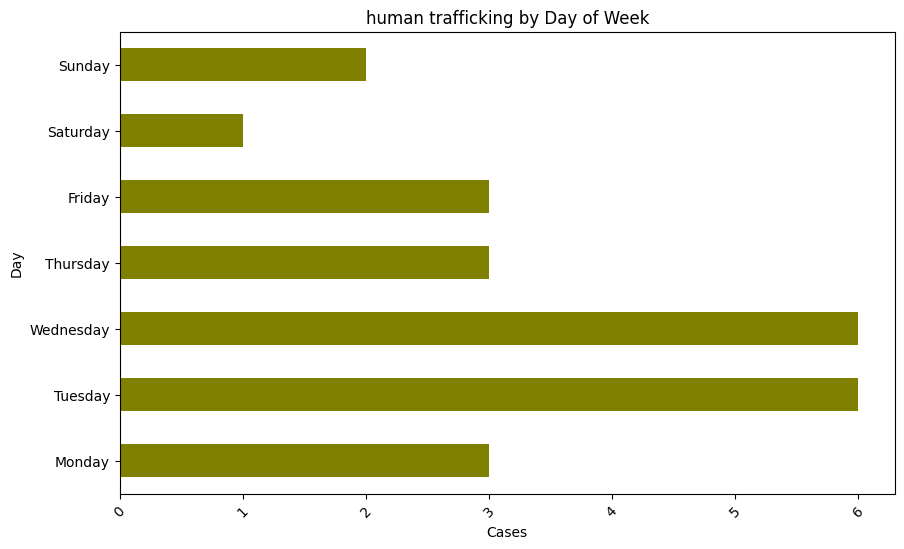

In [31]:
human_traf = crimes[crimes["Primary Type"]=="HUMAN TRAFFICKING"].groupby("DayOfWeek").size()
    
day_names = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}
human_traf.index = human_traf.index.map(day_names)


human_traf.plot(
    kind="barh", 
    title="human trafficking by Day of Week", 
    ylabel="Day", 
    xlabel="Cases",
    color="olive",
    figsize=(10,6)
)
plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>This bar plot shows the number of human trafficking cases recorded each day of the week. Tuesday and Wednesday recorded the highest number of human trafficking cases, with approximately 6 cases each. Saturday recorded the lowest number of human trafficking cases, with only 1 case. This suggests that human trafficking is more frequent during the early weekdays, particularly on Tuesdays and Wednesdays.</h5>

<h3>17.) Which district records the highest number of crimes each year?
</h3>

<Axes: title={'center': 'Crimes by District per Year'}, xlabel='District'>

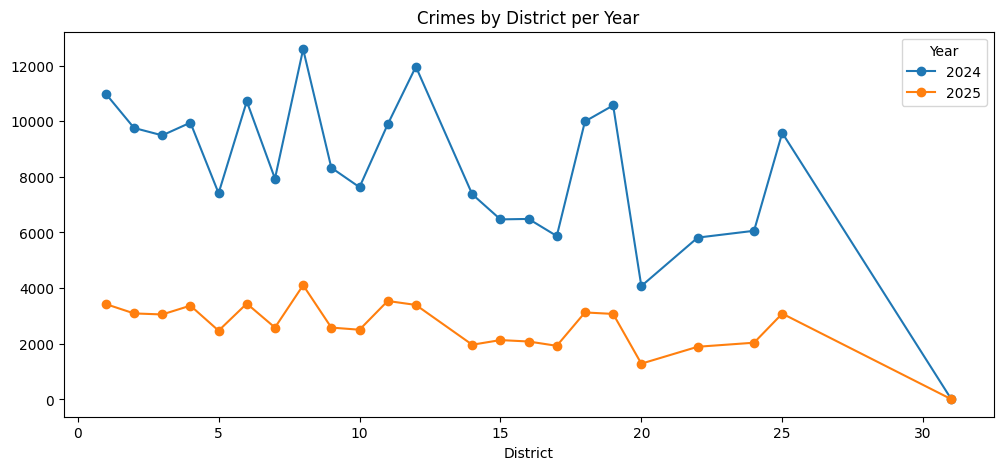

In [32]:
crimes_per_year = crimes.groupby(["Year","District"]).size().unstack().T 
crimes_per_year.plot(
    title="Crimes by District per Year", 
    marker = "o", 
    figsize=(12,5))

<h5><b>INSIGHT:</b>The line chart illustrates the number of crimes per district in Chicago for the years 2024 and 2025. It shows that crime rates vary significantly across different districts. In 2024, some districts experienced much higher crime rates compared to others, while the crime rates in 2025 were generally lower across all districts compared to 2024. The district which records the highest crimes each year can be found by using the code provided.</h5>

<h3>18.) In which month are kidnapping cases in apartments most frequent?
</h3>

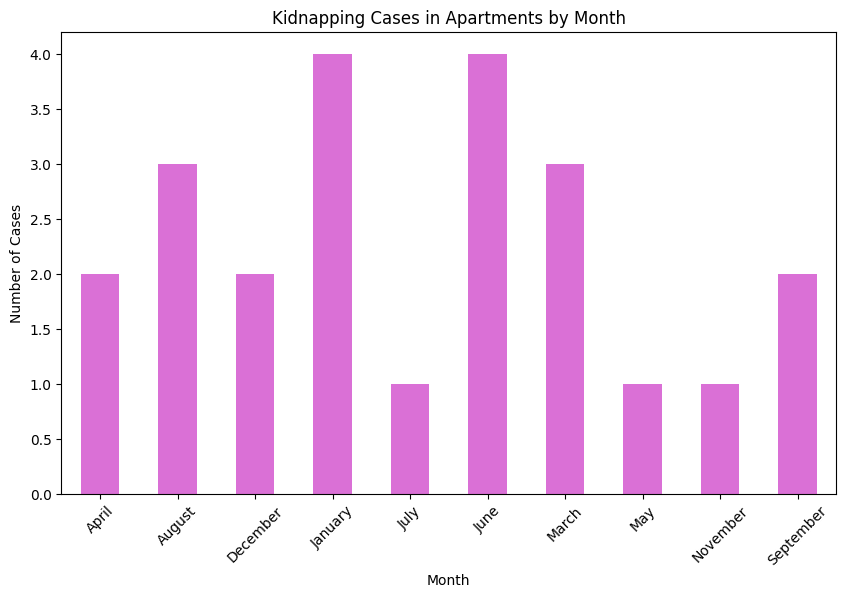

In [33]:
kidnapping_apartment = crimes[
    (crimes["Primary Type"] == "KIDNAPPING") & (crimes["Location Description"] == "APARTMENT")
]

month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
kidnapping_apartment["Month"] = kidnapping_apartment["Month"].map(month_names)

kidnapping_apartment.groupby("Month").size().plot(
    kind="bar",
    title="Kidnapping Cases in Apartments by Month",
    color="orchid",
    xlabel="Month",
    ylabel="Number of Cases",
    figsize=(10,6)
)

plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>This resent the number of kidnapping cases in apartments recorded each month. January recorded the highest number of kidnapping cases, with approximately 4 cases. May and July recorded the lowest number of kidnapping cases, with only 1 case each. This suggests that kidnapping in apartments is more frequent in January and June.</h5>

<h3>19.) Are weekends associated with a higher number of crimes compared to weekdays?

</h3>

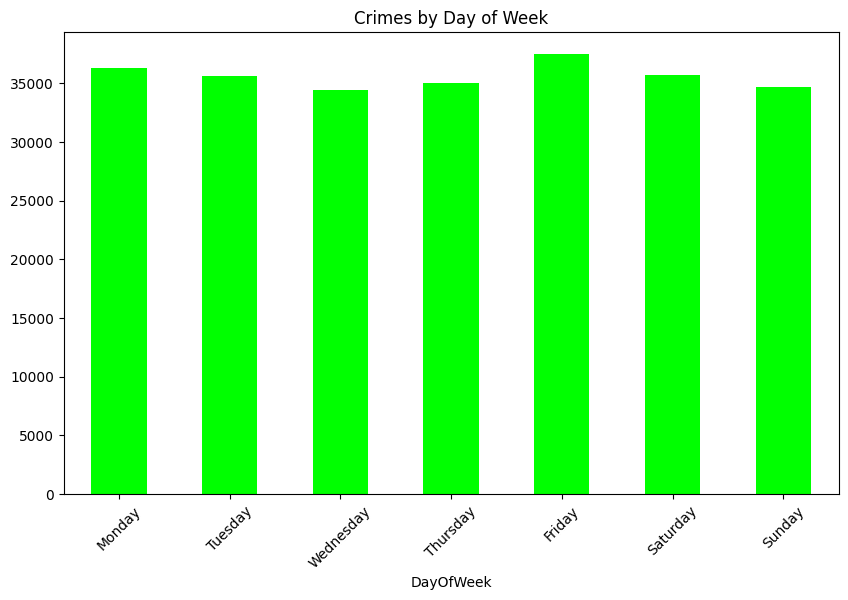

In [34]:
crimes_record = crimes.groupby("DayOfWeek").size()

day_names = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}
crimes_record.index = crimes_record.index.map(day_names)


crimes_record.plot(
    kind="bar", 
    title="Crimes by Day of Week",
    color="lime",
    figsize=(10,6))
plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>The plot presents the total number of crimes recorded each day of the week. Overall, crime occurrences remain relatively consistent, ranging from approximately 30,000 to 37,000 cases. Friday exhibits a slightly higher number of crimes compared to other days. These findings suggest that the overall crime rate is not substantially influenced by the day of the week.</h5>

<h3>20.) WWhat is the distribution of crimes that occurred in January across different years according to the dataset?
</h3>

<Axes: title={'center': 'January Crimes per Year'}, ylabel='1'>

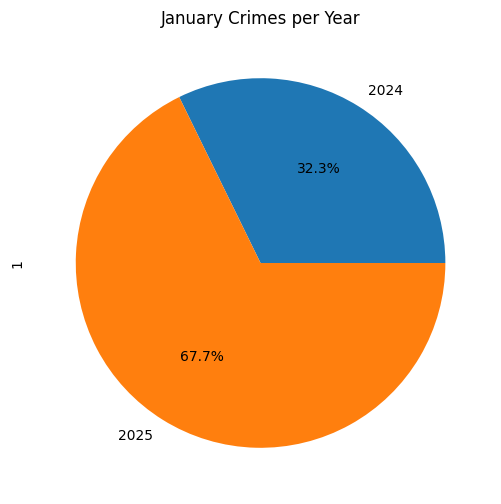

In [35]:
jan_crimes = crimes.groupby(["Year","Month"]).size().unstack().T.loc[1]
    
jan_crimes.plot(
    kind="pie", 
    autopct = '%1.1f%%', 
    title="January Crimes per Year",
    figsize=(10,6))


<h5><b>INSIGHT:</b>The pie chart titled “January Crimes per Year” illustrates the proportion of crimes recorded in January for the years 2024 and 2025. From the visualization, January 2024 accounted for 32.3% of the total January crimes across the two years.January 2025 accounted for 67.7%, indicating a notable increase in crime incidents compared to January 2024.</h5>

<h3>21.) In which month do liquor law violation cases in business offices most frequently occur?

</h3>

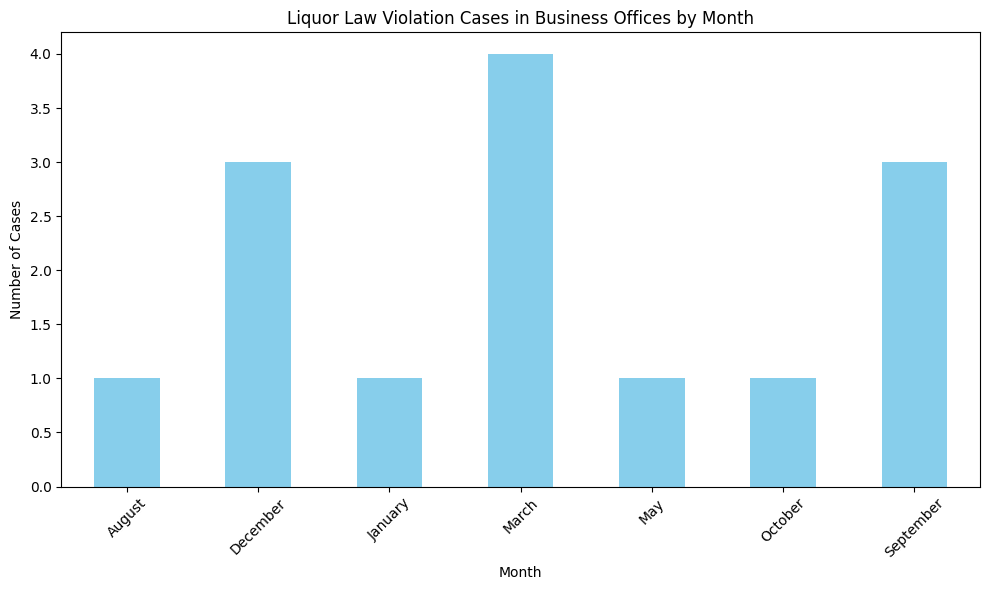

In [36]:
liquor_office = crimes[
    (crimes["Primary Type"] == "LIQUOR LAW VIOLATION") & 
    (crimes["Location Description"] == "COMMERCIAL / BUSINESS OFFICE")]

month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
liquor_office["Month"]= liquor_office["Month"].map(month_names)


liquor_office.groupby("Month").size().plot(
    kind="bar",
    title="Liquor Law Violation Cases in Business Offices by Month",
    xlabel="Month",
    ylabel="Number of Cases",
    figsize=(10, 6),
    color="skyblue"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<h5><b>INSIGHT:</b>This plot tells us the number of liquor law violation cases in business offices recorded each month. March recorded the highest number of liquor law violation cases, with approximately 4 cases. August, January, May and October recorded the lowest number of liquor law violation cases, with only 1 case each. This suggests that liquor law violations in business offices are more frequent in March..</h5>

<h3>22.) What is the most common crime that occurs in car wash locations?
</h3>

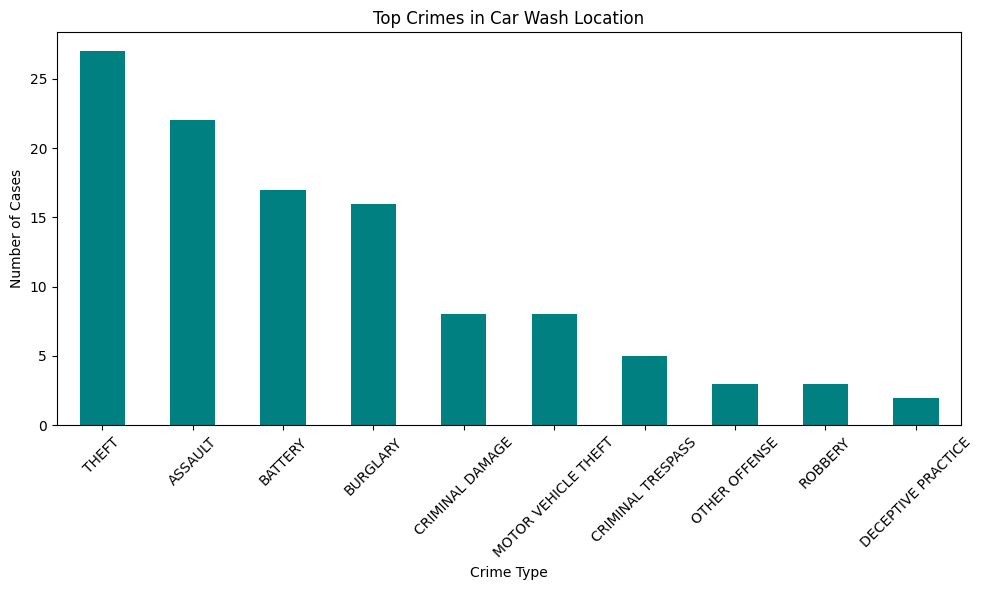

In [53]:
car_wash_crimes = crimes[crimes["Location Description"] == "CAR WASH"]


car_wash_common = car_wash_crimes["Primary Type"].value_counts().head(1)

car_wash_crimes["Primary Type"].value_counts().head(10).plot(
    kind="bar",
    title="Top Crimes in Car Wash Location",
    xlabel="Crime Type",
    ylabel="Number of Cases",
    figsize=(10,6),
    color="teal"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h5><b>INSIGHT:</b>The bar plot depicts the distribution of crime types occurring in car wash locations. Theft emerges as the most prevalent crime, with approximately 26 reported cases, followed by assault with around 22 cases. Deceptive practice is the least frequent, accounting for only about 1 case. These findings indicate that theft constitutes the primary security concern in car wash settings.</h5>

<h3>23.) What are the arrest rates for domestic versus non-domestic incidents?
</h3>

<Axes: title={'center': 'Arrest Rate for Domestic vs Non-Domestic'}, ylabel='Arrest'>

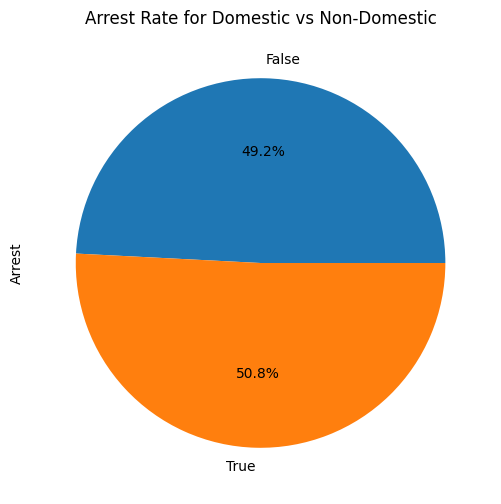

In [38]:
higher_arrest = crimes.groupby("Domestic")["Arrest"].mean()
    
higher_arrest.plot(
    kind="pie",
    autopct = '%1.1f%%', 
    title="Arrest Rate for Domestic vs Non-Domestic",
    figsize=(10,6))

<h5><b>INSIGHT:</b>The pie chart illustrates arrest rates for domestic and non-domestic incidents. Domestic incidents exhibit a slightly higher arrest rate at 50.8%, compared to 49.2% for non-domestic incidents, indicating a marginal difference in law enforcement outcomes between the two categories.</h5>

<h3>24.) What year recorded the highest overall arrest percentage?

</h3>

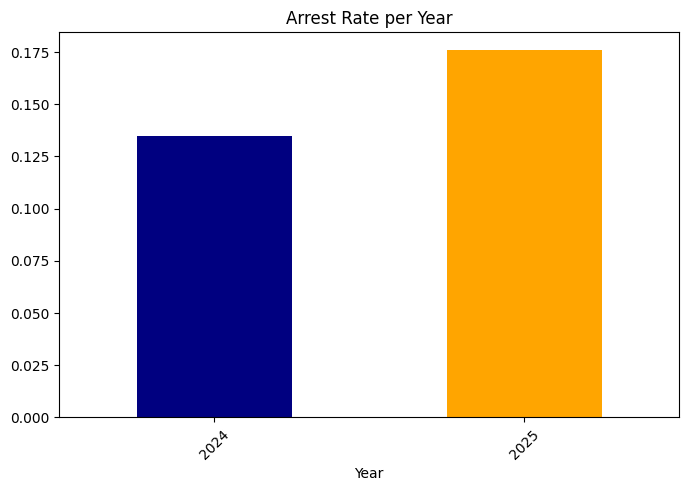

In [39]:
overall = crimes.groupby("Year")["Arrest"].mean()
    
overall.plot(
    kind="bar", 
    title="Arrest Rate per Year",
    color=["navy","orange"],
    figsize=(8,5))

plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>The bar chart illustrates the average arrest rate per year. From the visualization, it is evident that 2025 recorded a higher overall arrest rate compared to 2024. This indicates an increase in law enforcement effectiveness or reporting in 2025 relative to the previous year.</h5>


<h3>25.) Which locations have the highest arrest rates compared to others?

</h3>

<Axes: title={'center': 'Arrest Rate by Location Description'}, ylabel='Location Description'>

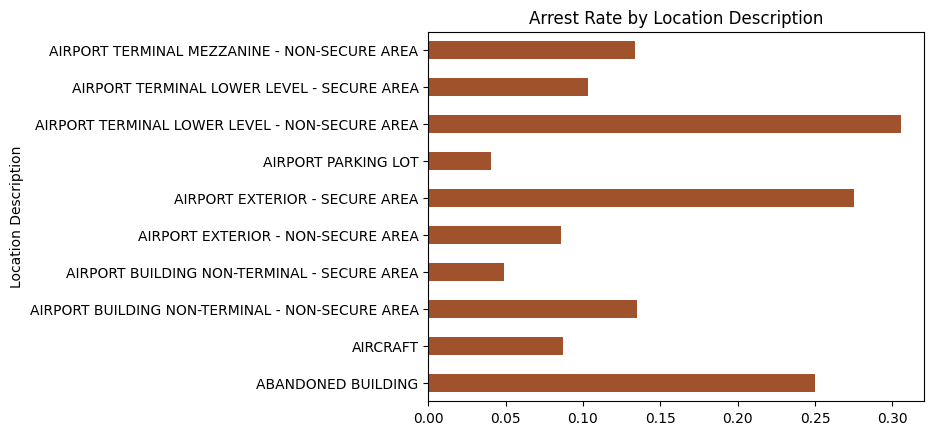

In [40]:
loc_rates = crimes.groupby("Location Description")["Arrest"].mean().head(10)
    
loc_rates.plot(
    kind="barh",
    color="sienna",
    title="Arrest Rate by Location Description")

<h5><b>INSIGHT:</b>The bar plot presents arrest rates across different location types. Abandoned buildings exhibit the highest arrest rate, approximately 0.3, followed by Airport Exterior – Secure Area at around 0.25. Aircraft locations show the lowest arrest rate, close to 0.0. These findings indicate that arrest rates vary considerably depending on the location.</h5>

<h3>26.) Which month usually records the highest number of weapons violation cases?
</h3>

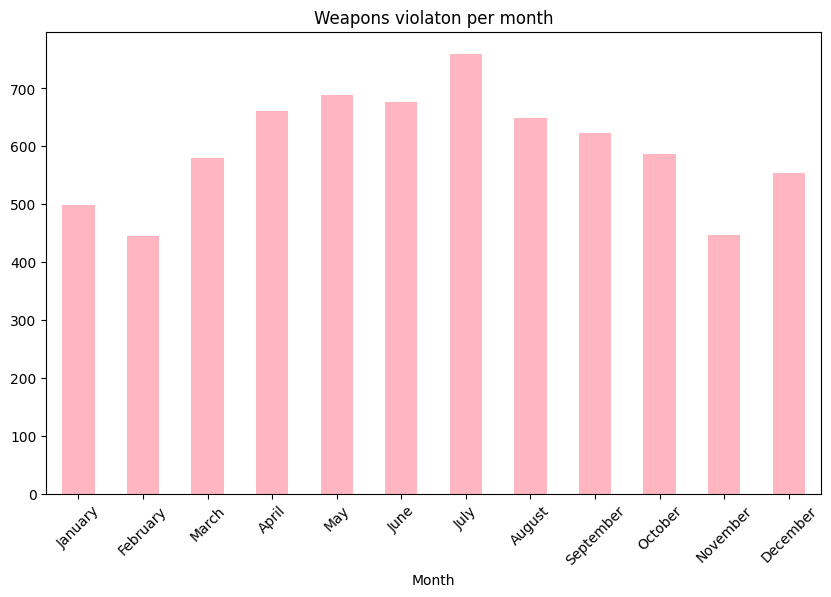

In [41]:
weapons = crimes[crimes["Primary Type"]=="WEAPONS VIOLATION"].groupby("Month").size()

month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
weapons.index = weapons.index.map(month_names)

weapons.plot(
    kind="bar", 
    title="Weapons violaton per month",
    color="lightpink",
    figsize=(10,6))
plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>The bar plot depicts the monthly distribution of weapons violations. July recorded the highest incidence, with approximately 700 cases, while January and November reported the lowest, at around 500 cases each. This pattern suggests that weapons violations are more frequent during the summer months, particularly in July.</h5>

<h3>27.) Are assault cases more common on weekends than weekdays?

</h3>

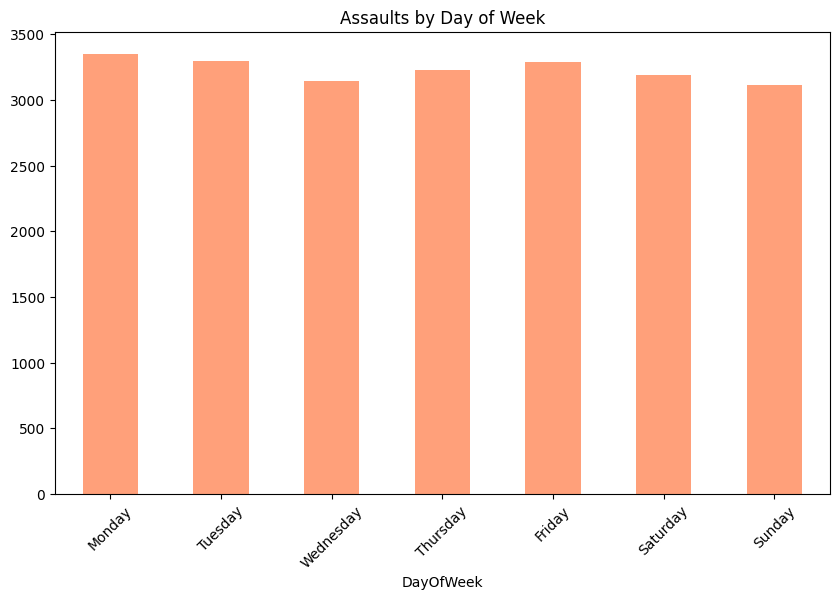

In [42]:
assult_dow = crimes[crimes["Primary Type"]=="ASSAULT"].groupby("DayOfWeek").size()
    
day_names = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}
assult_dow.index = assult_dow.index.map(day_names)

assult_dow.plot(
    kind="bar", 
    title="Assaults by Day of Week",
    color="lightsalmon",
    figsize=(10,6))

plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>The bar plot presents the distribution of assault cases across the days of the week. The number of assaults remains relatively consistent, ranging from approximately 3,100 to 3,400 cases. Tuesday through Sunday exhibit slightly higher incidences compared to Monday. Overall, this pattern indicates that the occurrence of assaults is not substantially influenced by the day of the week.</h5>

<h3>28.) Which years recorded the highest number of burglary crimes?
</h3>

<Axes: title={'center': 'Burglary Crimes per Year'}>

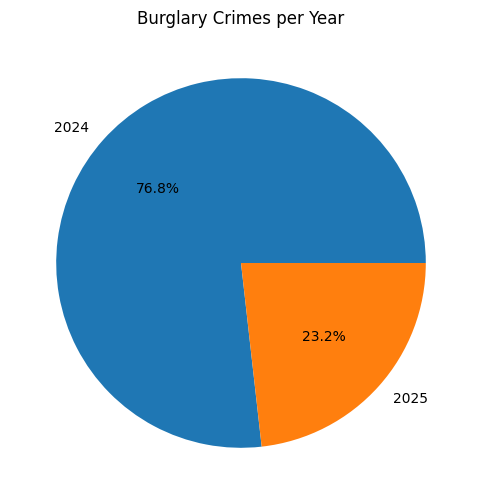

In [43]:
bulgary_per_year = crimes[crimes["Primary Type"]=="BURGLARY"].groupby("Year").size()
    
bulgary_per_year.plot(
    kind="pie", 
    autopct = '%1.1f%%', 
    title="Burglary Crimes per Year",
    figsize=(10,6))

<h5><b>INSIGHT:</b>The pie chart titled “Burglary Crimes per Year” illustrates the distribution of burglary incidents across 2024 and 2025. The data reveals that the majority of burglary crimes occurred in 2024, accounting for 76.8% of total cases, while 2025 recorded a significantly lower proportion of 23.2%. This indicates a notable decrease in burglary incidents in the most recent year.</h5>

<h3>29.) Between narcotics and theft, which crime type has a higher arrest rate over the years?

</h3>

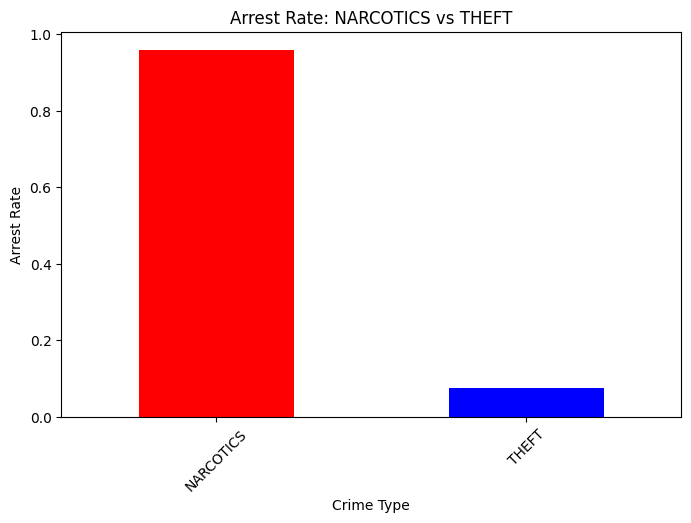

In [52]:
drug_theft = crimes[crimes["Primary Type"].isin(["NARCOTICS", "THEFT"])]


arrest_rate = drug_theft.groupby("Primary Type")["Arrest"].mean()


arrest_rate = arrest_rate.loc[["NARCOTICS", "THEFT"]]


arrest_rate.plot(
    kind="bar",
    title="Arrest Rate: NARCOTICS vs THEFT",
    xlabel="Crime Type",
    ylabel="Arrest Rate",
    color=["red", "blue"],
    figsize=(8,5)
)

plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>This bar chart compares the arrest rates for narcotics-related offenses and theft. The data demonstrates a significantly elevated arrest rate for narcotics crimes relative to theft, underscoring the focus and effectiveness of law enforcement efforts in addressing narcotics offenses.</h5>

<h3>30.) Which month recorded the highest number of motor vehicle theft cases?
</h3>

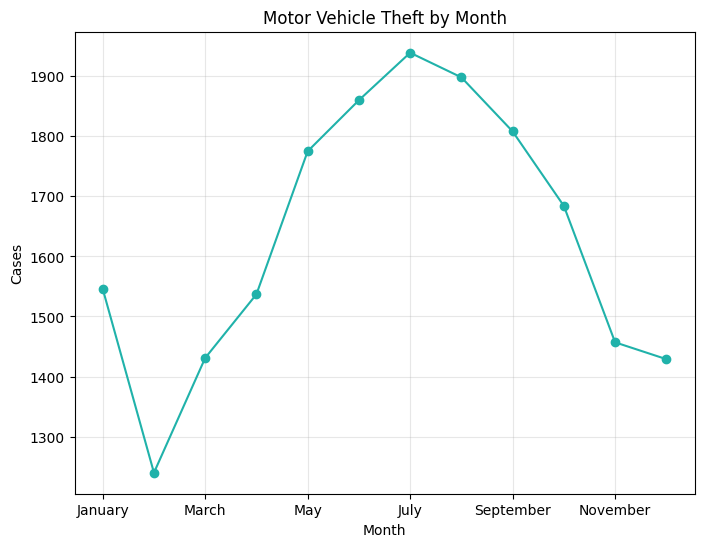

In [45]:
motor = crimes[crimes["Primary Type"]=="MOTOR VEHICLE THEFT"].groupby("Month").size()
    
month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
motor.index = motor.index.map(month_names)

motor.plot(
    kind="line", 
    marker="o", 
    title="Motor Vehicle Theft by Month", 
    xlabel="Month", 
    ylabel="Cases",
    color="lightseagreen",
    figsize=(8,6)
   
)
plt.grid(alpha=0.3)
plt.show()


<h5><b>INSIGHT:</b>This line plot illustrates the number of motor vehicle thefts recorded each month. August recorded the highest number of motor vehicle thefts, with approximately 1900 cases. February recorded the lowest number of motor vehicle thefts, with approximately 1250 cases. This suggests that motor vehicle thefts are more frequent during the summer months, particularly in August.


</h5>

<h3>31.) Which month recorded the highest number of battery crimes?
</h3>

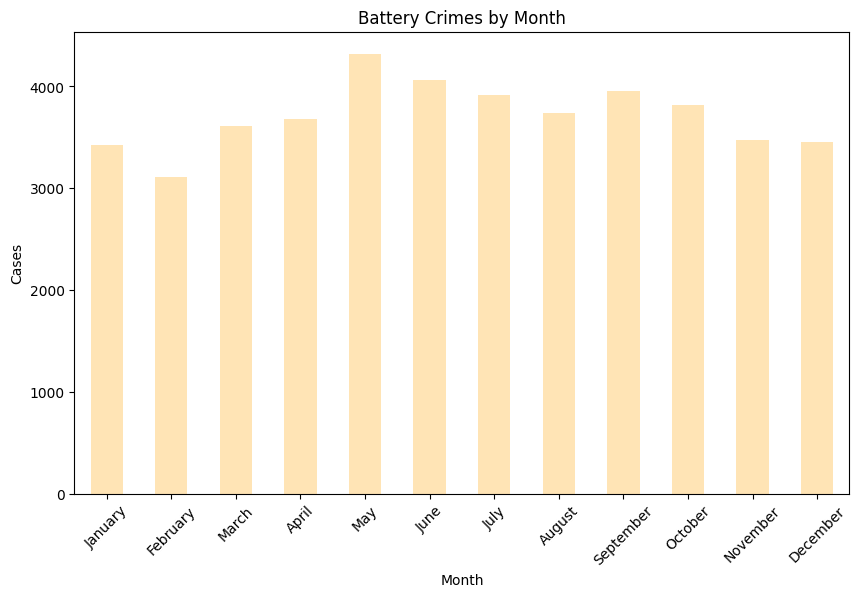

In [46]:
battery_per_month = crimes[crimes["Primary Type"]=="BATTERY"].groupby("Month").size()
    
month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
battery_per_month.index = battery_per_month.index.map(month_names)


battery_per_month.plot(
    kind="bar",
    title="Battery Crimes by Month", 
    xlabel="Month", 
    ylabel="Cases",
    color="moccasin",
    figsize=(10,6)
)
plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>This bar plot shows the number of battery crimes recorded each month. May has the highest number of battery crimes, with approximately 4200 cases. June, July, August, September, October, November, and December each have between 3500 and 4000 cases. January, March, and April each have between 3500 and 3800 cases. February has the lowest number of battery crimes, with approximately 3100 cases. </h5>

<h3>32.) What is the monthly distribution of criminal damage incidents occurring on private school grounds, and which months record the highest and lowest frequencies of such cases?
</h3>

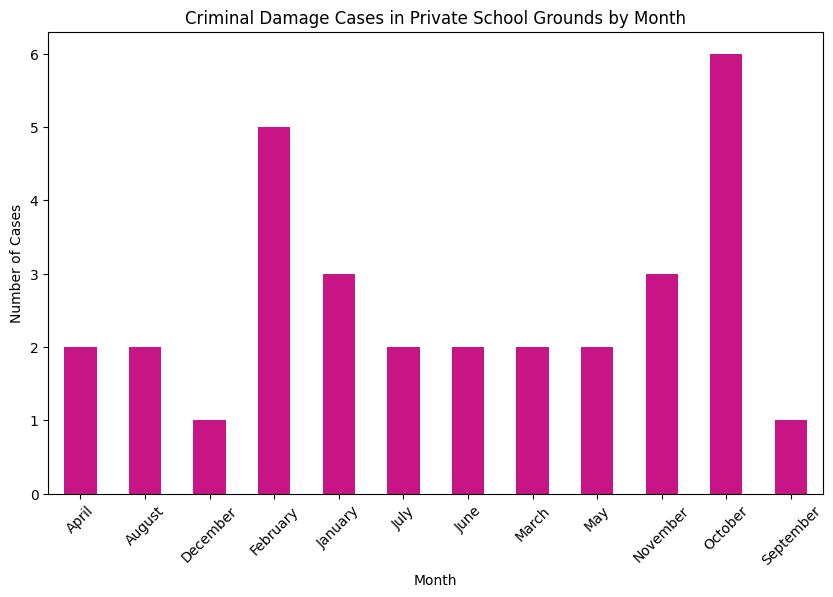

In [47]:
sexual_assault_school = crimes[
    (crimes["Primary Type"] == "CRIMINAL DAMAGE") & 
    (crimes["Location Description"] == "SCHOOL - PRIVATE GROUNDS")
]


month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
sexual_assault_school["Month"] = sexual_assault_school["Month"].map(month_names)

sexual_assault_school.groupby("Month").size().plot(
    kind="bar",
    title="Criminal Damage Cases in Private School Grounds by Month",
    xlabel="Month",
    ylabel="Number of Cases",
    figsize=(10, 6),
    color="mediumvioletred"
)

plt.xticks(rotation=45)
plt.show()

<h5><b>INSIGHT:</b>The bar plot illustrates the monthly distribution of concealed carry license violations occurring in bars or taverns. Cases are recorded only in the months of April and August, with one case each, while no violations are reported in the other months. This indicates that such offenses are rare and occur sporadically throughout the year.</h5>

<h3>33.) Which day of the week experiences the highest number of residential arson cases?
</h3>

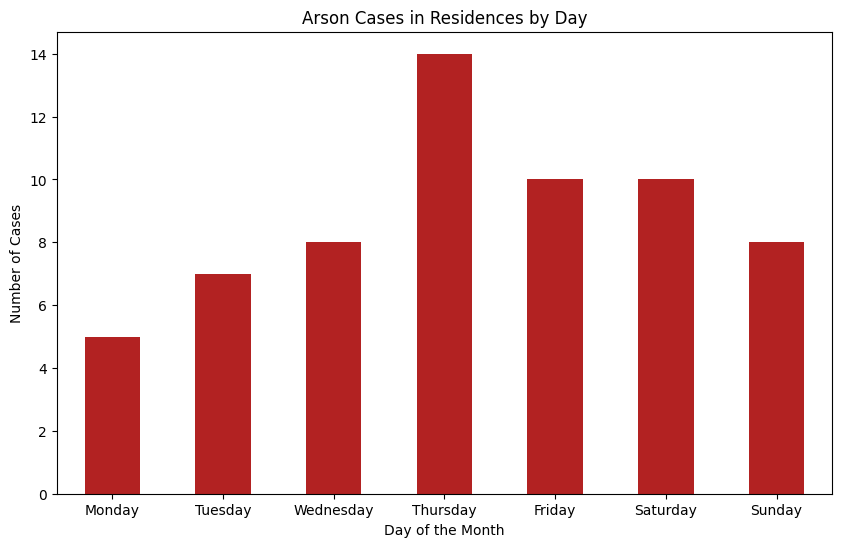

In [48]:
arson_residence = crimes[
    (crimes["Primary Type"] == "ARSON") & 
    (crimes["Location Description"] == "RESIDENCE")
]

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


day_names = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}
arson_residence["DayOfWeek"] = arson_residence["DayOfWeek"].map(day_names)

arson_residence["DayOfWeek"] = pd.Categorical(
    arson_residence["DayOfWeek"], 
    categories=day_order, 
    ordered=True
)
arson_residence.groupby("DayOfWeek").size().plot(
    
    kind="bar",
    title="Arson Cases in Residences by Day",
    xlabel="Day of the Month",
    ylabel="Number of Cases",
    figsize=(10, 6),
    color="firebrick"
)

plt.xticks(rotation=0)
plt.show()

<h5><b>INSIGHT:</b>This bar plot shows the distribution of arson cases in residences by day of the week. The x-axis lists the days of the week, and the y-axis indicates the number of cases. Thursday has the highest number of arson cases, with approximately 14 cases. Friday and Saturday each have around 10 cases. Wednesday and Sunday have approximately 8 cases each. Tuesday has about 7 cases, and Monday has the fewest, with only 5 cases.</h5>

<h3>33.) How does the number of concealed carry license violation cases vary across the days of the week?
</h3>

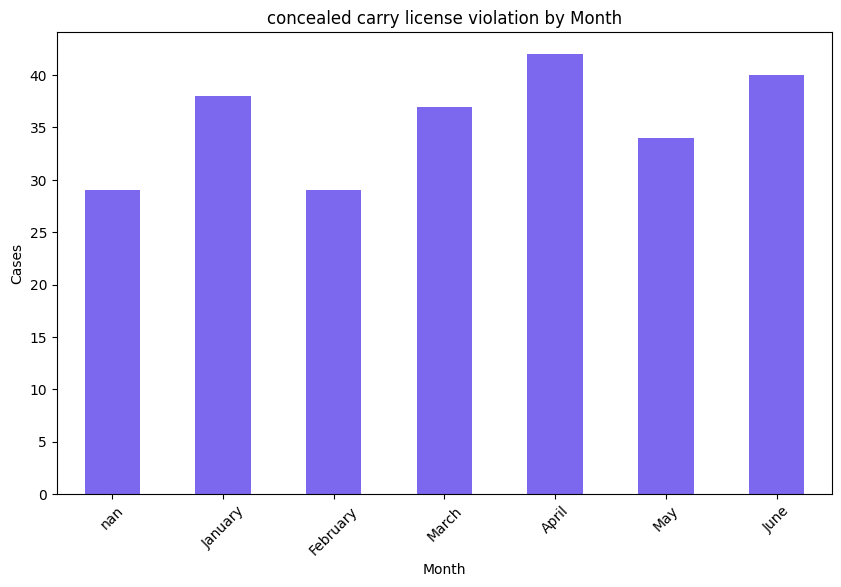

In [49]:
concealed  =  crimes[crimes["Primary Type"]=="CONCEALED CARRY LICENSE VIOLATION"].groupby("DayOfWeek").size()
    
month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
concealed.index = concealed.index.map(month_names)


concealed.plot(
    kind="bar", 
    title="concealed carry license violation by Month", 
    xlabel="Month",
    color="mediumslateblue",
    ylabel="Cases",
     figsize=(10, 6),
)
plt.xticks(rotation=45)
plt.show()


<h5><b>INSIGHT:</b>The bar chart illustrates the monthly distribution of concealed carry license violation cases. The data shows that April recorded the highest number of cases, with approximately 42 incidents, while January and February reported relatively lower numbers, around 29–38 cases. This suggests that concealed carry license violations fluctuate throughout the year, with a notable peak in April.</h5>

<h3>34.) In which month do Assault occur most often in bars or taverns?
</h3>

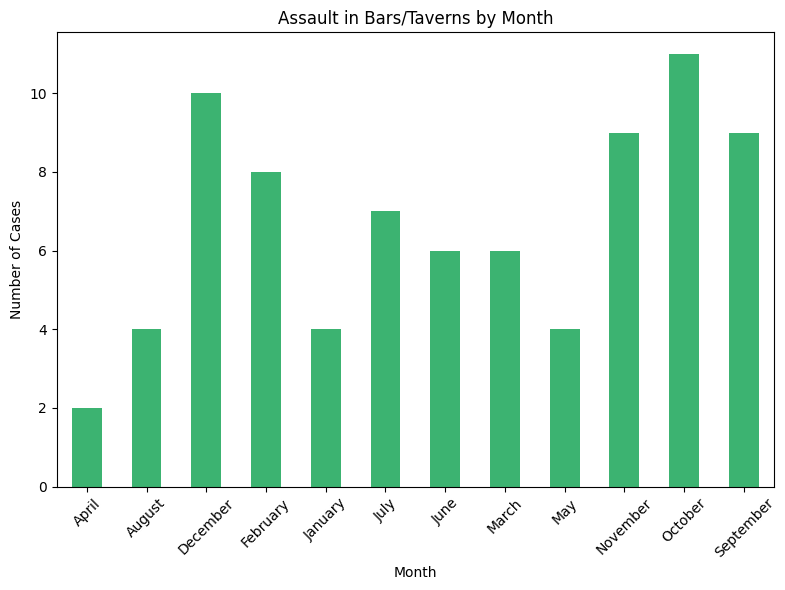

In [50]:
bar_carry = crimes[
    (crimes["Primary Type"] == "ASSAULT") & 
    (crimes["Location Description"] == "BAR OR TAVERN")
]


month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
bar_carry["Month"] = bar_carry["Month"].map(month_names)


bar_carry.groupby("Month").size().plot(
    kind="bar",
    title="Assault in Bars/Taverns by Month",
    xlabel="Month",
    ylabel="Number of Cases",
    figsize=(8, 6),
    color="mediumseagreen"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h5><b>INSIGHT:</b>The bar chart illustrates the monthly distribution of assault incidents within bars and taverns, highlighting temporal trends. The data shows a pronounced peak in October, with 11 reported cases, representing the highest monthly incidence. In contrast, April records the lowest number of assaults. This pattern suggests potential seasonal variation in criminal activity, which may be influenced by factors such as weather, tourism, or local events.</h5>

<h3>35.) What are the most common types of crimes that occur in police facilities or vehicle parking lots?

</h3>

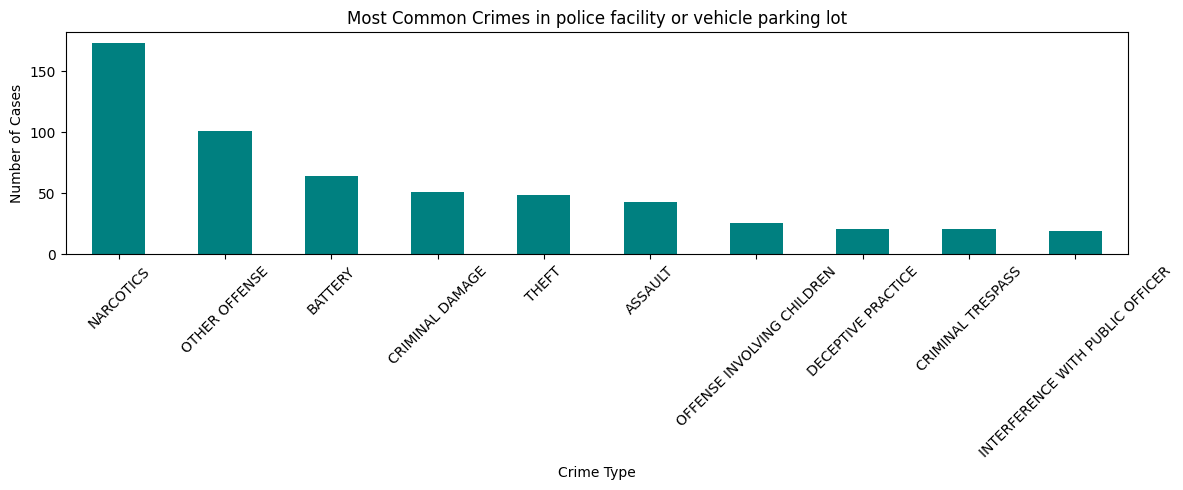

In [51]:
hotel_motel_crimes = crimes[crimes["Location Description"] == "POLICE FACILITY / VEHICLE PARKING LOT"]


hotel_motel_crimes["Primary Type"].value_counts().head(10).plot(
    kind="bar",
    figsize=(12, 5),
    title="Most Common Crimes in police facility or vehicle parking lot",
    color="teal"
)

plt.xlabel("Crime Type")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h5><b>INSIGHT:</b>This bar plot displays the distribution of crime types within police facilities or vehicle parking lots. Narcotics offenses are the most frequent, exceeding 150 cases, indicating a significant issue within these locations. "Other Offense" is the second most common, with approximately 100 cases. Following these, Battery, Criminal Damage, and Theft each range between 50 and 75 cases. Assault, Offense Involving Children, Deceptive Practice, Criminal Trespass, and Interference with Public Officer each have fewer than 50 cases.</h5>